In [2]:
import numerical_solver as ns

constants for numerical solver 

In [3]:
#size of domain
Lx = 10.0
Ly = 10.0
# number of grid points
nx = 100
ny = 100
# diffusion coef
D = 0.08
# cfl for stability
cfl = 0.3
# advection velocity
v_right = 1.0
v_up = -0.7
# gaussian pulse
x0 = [3.0, 5.0]
y0 = [5.0, 6.5]
sigma = [0.4, 0.4]
amplitude = [1.0, 1.0]
# final time
t_final = 3
# crop margin
x_margin = 1.5
y_margin = 1.5
# number of plots
num_plots = 10

numerical solver

Time step: dt = 0.015942
Maximum divergence: 0.000000

Starting RK4 simulation...
Total steps: 188
✓ Evolution figure saved!


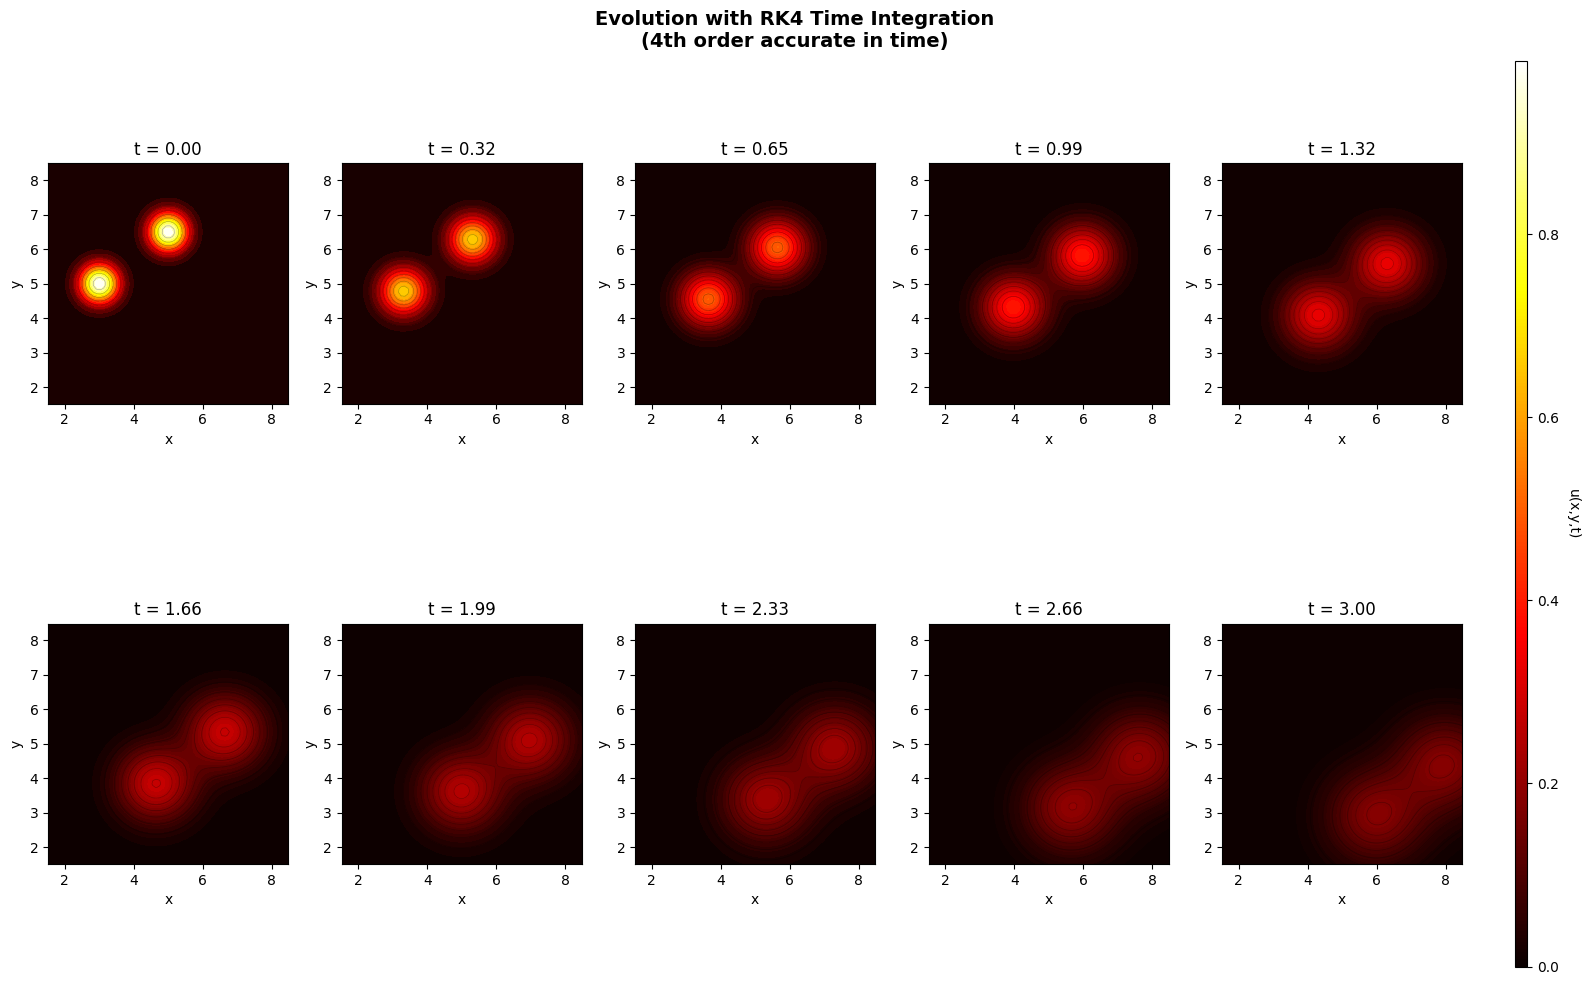

In [4]:
num_solver = ns.AdvectionDiffusion2D(Lx, Ly, nx, ny, D, cfl)
for x_0, y_0, sigma_, amplitude_ in zip(x0, y0, sigma, amplitude):
    num_solver.add_gaussian_pulse(x_0, y_0, sigma_, amplitude_)
vx, vy = ns.create_velocity_field_uniform(num_solver.X, num_solver.Y, v_right, v_up)
num_solver.set_velocity_field(vx, vy)
div = num_solver.check_divergence()
T, snapshots = num_solver.solve(t_final)
X, Y, U = ns.crop_data(num_solver.X, num_solver.Y, snapshots, x_margin, y_margin)
vmax = max([s.max() for s in U])
ns.create_visualisation(X, Y, U, T, num_plots, vmax)

I have X, Y which are the coordinates of the grid. I have U which has a 2D array for each time step containing the scalar value of the feature and T which has the time passed for each value in the array.

sinn solver

In [6]:
import pickle
import os

# Get the current working directory
save_path = os.path.join(os.getcwd(), 'data.pkl')

# Save variables to a pickle file
data = {'X': X, 'Y': Y, 'U': U, 'T': T}
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Variables saved to {save_path}")

Variables saved to c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\data.pkl
